# Deep Learning from Scratch with NumPy
## Diabetes Prediction - notebook chuẩn cho `diabetes_02.csv`

Notebook xây dựng đầy đủ pipeline:

**Raw CSV → kiểm tra → làm sạch → train/validation/test → encode/scale → MLP 5 tầng → đánh giá → baseline → persistence**

Kiến trúc có đúng 5 tầng học tham số:

$$X(B,d)\rightarrow H_1(B,128)\rightarrow H_2(B,64)\rightarrow H_3(B,32)\rightarrow H_4(B,16)\rightarrow Z(B,1)\rightarrow\sigma(Z)$$

Đây là mô hình hỗ trợ sàng lọc học thuật, không thay thế chẩn đoán của bác sĩ.

## 1. Import và cấu hình

In [1]:
from pathlib import Path
import copy, time, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display
except ImportError:
    display=print

warnings.filterwarnings("ignore")
SEED=42
rng=np.random.default_rng(SEED)
sns.set_theme(style="whitegrid")
HERE=Path.cwd(); DATA_DIR=HERE/"upload" if (HERE/"upload").exists() else HERE
MODEL_DIR=HERE/"models"; MODEL_DIR.mkdir(exist_ok=True)
FAST_MODE=True  # False khi cần chạy cấu hình báo cáo cuối
print("FAST_MODE:",FAST_MODE)

FAST_MODE: True


## 2. Load và hiểu dữ liệu

Một dòng là một hồ sơ bệnh nhân. `diabetes` là nhãn nhị phân. Các cột `gender`, `location`, `smoking_history` là categorical; các cột race trong file đã ở dạng chỉ báo 0/1.

In [2]:
path=DATA_DIR/"diabetes_02.csv"
df=pd.read_csv(path)
print("Path:",path.resolve()); print("Shape:",df.shape)
display(df.head()); df.info(); display(df.describe(include="all").T)
display(df.isna().sum().to_frame("missing")); print("Duplicated rows:",df.duplicated().sum())
display(df["diabetes"].value_counts().rename_axis("class").to_frame("count").assign(percent=lambda x:100*x["count"]/x["count"].sum()))

Path: C:\Users\hhai6\diabetes_02.csv
Shape: (100000, 16)


,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  str    
 2   age                   100000 non-null  float64
 3   location              100000 non-null  str    
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  str    
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  diabetes    

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
year,100000.0,NaN,NaN,NaN,2018.36082,1.345239,2015.0,2019.0,2019.0,2019.0,2022.0
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
location,100000,55,Hawaii,2038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race:AfricanAmerican,100000.0,NaN,NaN,NaN,0.20223,0.401665,0.0,0.0,0.0,0.0,1.0
race:Asian,100000.0,NaN,NaN,NaN,0.20015,0.400114,0.0,0.0,0.0,0.0,1.0
race:Caucasian,100000.0,NaN,NaN,NaN,0.19876,0.399069,0.0,0.0,0.0,0.0,1.0
race:Hispanic,100000.0,NaN,NaN,NaN,0.19888,0.39916,0.0,0.0,0.0,0.0,1.0
race:Other,100000.0,NaN,NaN,NaN,0.19998,0.399987,0.0,0.0,0.0,0.0,1.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0


,missing
year,0
gender,0
age,0
location,0
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0
hypertension,0


Duplicated rows: 14


,count,percent
class,,
0,91500,91.5
1,8500,8.5


## 3. Kiểm tra dữ liệu không hợp lệ và làm sạch

- Xóa dòng trùng để một hồ sơ không được tính nhiều lần.
- Giá trị không dương ở BMI, HbA1c hoặc glucose không hợp lý; chuyển thành thiếu và median-impute **fit trên train**.
- Không xóa outlier hợp lệ tùy tiện vì ca bệnh hiếm có thể mang tín hiệu quan trọng.
- `year` được giữ như numeric context; cần xác nhận ý nghĩa thời gian khi triển khai thực tế.

In [3]:
df=df.drop_duplicates().copy()
for c in ["bmi","hbA1c_level","blood_glucose_level"]:
    invalid=df[c]<=0
    print(c,"invalid <= 0:",int(invalid.sum()))
    df.loc[invalid,c]=np.nan
assert df["diabetes"].isin([0,1]).all()
print("Clean shape:",df.shape)

bmi invalid <= 0: 0
hbA1c_level invalid <= 0: 0
blood_glucose_level invalid <= 0: 0
Clean shape: (99986, 16)


## 4. EDA: Observation → Interpretation → ML implication

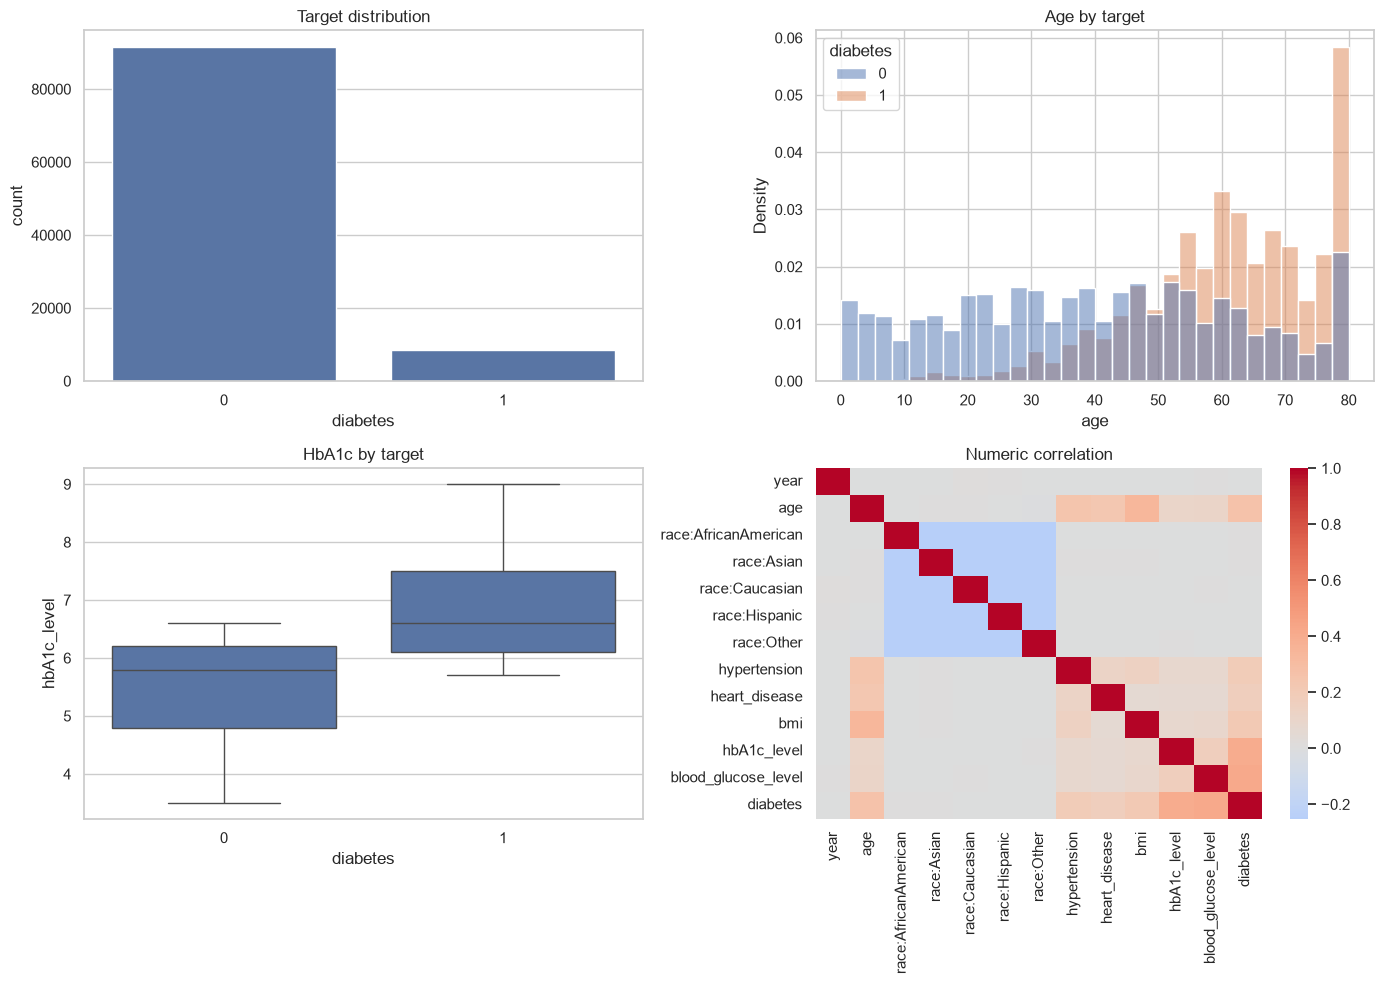

Observation: lớp 1 ít hơn rõ rệt; HbA1c/glucose/age thường có phân bố khác giữa hai lớp.
Interpretation: có tín hiệu lâm sàng nhưng correlation không chứng minh nhân quả.
ML implication: stratified split, weighted loss; ưu tiên Recall/F2 và theo dõi false negative.


In [4]:
sample=df.sample(min(20000,len(df)),random_state=SEED)
fig,ax=plt.subplots(2,2,figsize=(14,10))
sns.countplot(data=df,x="diabetes",ax=ax[0,0]); ax[0,0].set_title("Target distribution")
sns.histplot(data=sample,x="age",hue="diabetes",bins=30,stat="density",common_norm=False,ax=ax[0,1]); ax[0,1].set_title("Age by target")
sns.boxplot(data=sample,x="diabetes",y="hbA1c_level",showfliers=False,ax=ax[1,0]); ax[1,0].set_title("HbA1c by target")
sns.heatmap(df.select_dtypes(include=np.number).corr(),cmap="coolwarm",center=0,ax=ax[1,1]); ax[1,1].set_title("Numeric correlation")
plt.tight_layout(); plt.show()
print("Observation: lớp 1 ít hơn rõ rệt; HbA1c/glucose/age thường có phân bố khác giữa hai lớp.")
print("Interpretation: có tín hiệu lâm sàng nhưng correlation không chứng minh nhân quả.")
print("ML implication: stratified split, weighted loss; ưu tiên Recall/F2 và theo dõi false negative.")

## 5. Chia 70/15/15 trước khi fit preprocessing

Train dùng để học trọng số và preprocessing; validation dùng chọn learning rate/threshold/epoch; test chỉ đánh giá đúng một lần sau khi chốt cấu hình.

In [5]:
from sklearn.model_selection import train_test_split
target="diabetes"
X=df.drop(columns=target); y=df[target].to_numpy(np.float32).reshape(-1,1)
Xtr_df,Xtmp_df,ytr,ytmp=train_test_split(X,y,test_size=.30,stratify=y.ravel(),random_state=SEED)
Xv_df,Xte_df,yv,yte=train_test_split(Xtmp_df,ytmp,test_size=.50,stratify=ytmp.ravel(),random_state=SEED)
print("Train/Validation/Test:",Xtr_df.shape,Xv_df.shape,Xte_df.shape)
for name,a in [("train",ytr),("validation",yv),("test",yte)]: print(name,"positive rate:",round(float(a.mean()),4))

Train/Validation/Test: (69990, 15) (14998, 15) (14998, 15)
train positive rate: 0.085
validation positive rate: 0.085
test positive rate: 0.085


## 6. Biểu diễn dữ liệu

- Numeric: median imputation + z-score.
- Categorical (`gender`, `location`, `smoking_history`): mode imputation + one-hot.
- Preprocessor chỉ fit trên train.
- Kết quả $X\in\mathbb{R}^{N\times d}$; mỗi row là một vector bệnh nhân.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

cat_cols=["gender","location","smoking_history"]
num_cols=[c for c in X.columns if c not in cat_cols]
prep=ColumnTransformer([
 ("num",Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())]),num_cols),
 ("cat",Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),("onehot",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]),cat_cols)
],sparse_threshold=0)
Xtr=prep.fit_transform(Xtr_df).astype(np.float32); Xv=prep.transform(Xv_df).astype(np.float32); Xte=prep.transform(Xte_df).astype(np.float32)
if FAST_MODE and len(Xtr)>30000:
    keep,_=train_test_split(np.arange(len(Xtr)),train_size=30000,stratify=ytr.ravel(),random_state=SEED)
    Xtr,ytr=Xtr[keep],ytr[keep]
print("Numerical columns:",num_cols); print("Categorical columns:",cat_cols)
print("Final model input:",Xtr.shape,Xv.shape,Xte.shape,"dtype:",Xtr.dtype)
print("First feature vector (first 20 values):",Xtr[0,:20])

Numerical columns: ['year', 'age', 'race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other', 'hypertension', 'heart_disease', 'bmi', 'hbA1c_level', 'blood_glucose_level']
Categorical columns: ['gender', 'location', 'smoking_history']
Final model input: (30000, 76) (14998, 76) (14998, 76) dtype: float32
First feature vector (first 20 values): [-1.765079    1.2967492  -0.50214225  1.9935045  -0.49953115 -0.49937484
 -0.49731958  3.5261567  -0.20104378  1.7863098   3.0546343   0.53647566
  1.          0.          0.          0.          0.          0.
  0.          0.        ]


## 7. Tensor shapes và số tham số

Với batch $B$: $B\times d\to B\times128\to B\times64\to B\times32\to B\times16\to B\times1$.

In [7]:
d=Xtr.shape[1]; architecture=[d,128,64,32,16,1]
rows=[]
for i,(din,dout) in enumerate(zip(architecture[:-1],architecture[1:]),1):
    rows.append({"Layer":i,"Weight shape":f"({din}, {dout})","Bias shape":f"(1, {dout})","Output":f"(B, {dout})","Parameters":din*dout+dout})
display(pd.DataFrame(rows)); print("Total trainable parameters:",sum(r["Parameters"] for r in rows))

,Layer,Weight shape,Bias shape,Output,Parameters
0,1,"(76, 128)","(1, 128)","(B, 128)",9856
1,2,"(128, 64)","(1, 64)","(B, 64)",8256
2,3,"(64, 32)","(1, 32)","(B, 32)",2080
3,4,"(32, 16)","(1, 16)","(B, 16)",528
4,5,"(16, 1)","(1, 1)","(B, 1)",17


Total trainable parameters: 20737


## 8. Activation, stable BCE, forward propagation và backpropagation

In [8]:
def relu(x): return np.maximum(x,0)
def relu_grad(x): return (x>0).astype(np.float32)
def sigmoid(x): return 1/(1+np.exp(-np.clip(x,-30,30)))

def init_mlp(dims,seed=42):
    r=np.random.default_rng(seed); p={}
    for i,(din,dout) in enumerate(zip(dims[:-1],dims[1:]),1):
        p[f"W{i}"]=(r.standard_normal((din,dout))*np.sqrt(2/din)).astype(np.float32)
        p[f"b{i}"]=np.zeros((1,dout),np.float32)
    return p

def forward(X,p,return_hidden=False):
    A=X; cache=[]; L=len(p)//2
    for i in range(1,L):
        Z=A@p[f"W{i}"]+p[f"b{i}"]; cache.append((A,Z)); A=relu(Z)
    logits=A@p[f"W{L}"]+p[f"b{L}"]; cache.append((A,logits)); prob=sigmoid(logits)
    hidden=[relu(v[1]) for v in cache[:-1]]
    return (prob,cache,hidden) if return_hidden else (prob,cache)

def weighted_bce(y,prob,w0=1.,w1=1.):
    prob=np.clip(prob,1e-7,1-1e-7); w=np.where(y==1,w1,w0)
    return float(np.mean(w*(-y*np.log(prob)-(1-y)*np.log(1-prob))))

def backward(prob,y,p,cache,w0,w1):
    n=len(y); L=len(p)//2; w=np.where(y==1,w1,w0); dZ=w*(prob-y)/n; g={}
    for i in range(L,0,-1):
        Aprev,Z=cache[i-1]; g[f"W{i}"]=Aprev.T@dZ; g[f"b{i}"]=dZ.sum(axis=0,keepdims=True)
        if i>1: dZ=(dZ@p[f"W{i}"].T)*relu_grad(cache[i-2][1])
    return g

## 9. Adam, mini-batch, gradient clipping và early stopping

In [9]:
def adam_step(p,g,state,t,lr=1e-3,clip=5.):
    norm=np.sqrt(sum(float((v*v).sum()) for v in g.values())); scale=min(1.,clip/(norm+1e-12))
    for k in p:
        q=g[k]*scale; state["m"][k]=.9*state["m"][k]+.1*q; state["v"][k]=.999*state["v"][k]+.001*q*q
        mh=state["m"][k]/(1-.9**t); vh=state["v"][k]/(1-.999**t); p[k]-=lr*mh/(np.sqrt(vh)+1e-8)

def train_network(Xtr,ytr,Xv,yv,dims,lr=.001,epochs=30,batch_size=256,weighted=True,patience=6,seed=42):
    p=init_mlp(dims,seed); state={"m":{k:np.zeros_like(v) for k,v in p.items()},"v":{k:np.zeros_like(v) for k,v in p.items()}}
    n0=(ytr==0).sum(); n1=(ytr==1).sum(); w0=len(ytr)/(2*n0) if weighted else 1.; w1=len(ytr)/(2*n1) if weighted else 1.
    history={"train":[],"validation":[]}; best={"loss":np.inf,"params":None,"epoch":0}; step=0; r=np.random.default_rng(seed)
    for epoch in range(epochs):
        indices=r.permutation(len(Xtr))
        for start in range(0,len(Xtr),batch_size):
            idx=indices[start:start+batch_size]; prob,cache=forward(Xtr[idx],p); grads=backward(prob,ytr[idx],p,cache,w0,w1); step+=1; adam_step(p,grads,state,step,lr)
        train_loss=weighted_bce(ytr,forward(Xtr,p)[0],w0,w1); val_loss=weighted_bce(yv,forward(Xv,p)[0],w0,w1)
        history["train"].append(train_loss); history["validation"].append(val_loss)
        if val_loss<best["loss"]-1e-5: best={"loss":val_loss,"params":copy.deepcopy(p),"epoch":epoch+1}
        elif epoch+1-best["epoch"]>=patience: break
    return best["params"],history,best["epoch"],{"class_0":float(w0),"class_1":float(w1)}

## 10. Exercise 1 - huấn luyện MLP 5 tầng

In [10]:
epochs=15 if FAST_MODE else 40
t0=time.time(); params,history,best_epoch,class_weights=train_network(Xtr,ytr,Xv,yv,architecture,lr=.001,epochs=epochs,batch_size=256,weighted=True)
print("Architecture:",architecture); print("Class weights:",class_weights); print("Best epoch:",best_epoch); print("Training time(s):",round(time.time()-t0,2))

Architecture: [76, 128, 64, 32, 16, 1]
Class weights: {'class_0': 0.546448087431694, 'class_1': 5.882352941176471}
Best epoch: 6
Training time(s): 7.27


## 11. Training/validation loss và overfitting

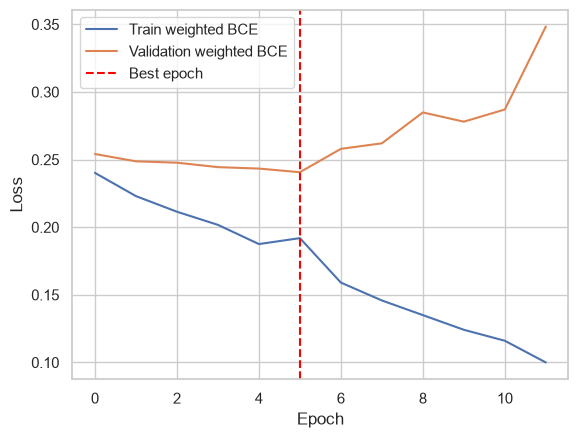

Nếu train loss giảm nhưng validation loss tăng, mạng đang overfit. Model đã khôi phục checkpoint tốt nhất.


In [11]:
plt.plot(history["train"],label="Train weighted BCE"); plt.plot(history["validation"],label="Validation weighted BCE")
plt.axvline(best_epoch-1,color="red",ls="--",label="Best epoch"); plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()
print("Nếu train loss giảm nhưng validation loss tăng, mạng đang overfit. Model đã khôi phục checkpoint tốt nhất.")

## 12. Metric functions và chọn threshold trên validation

In [12]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,fbeta_score,roc_auc_score,confusion_matrix
def metrics(y,prob,threshold=.5):
    yy=y.ravel().astype(int); pred=(prob.ravel()>=threshold).astype(int)
    return {"Accuracy":accuracy_score(yy,pred),"Precision":precision_score(yy,pred,zero_division=0),"Recall":recall_score(yy,pred,zero_division=0),"F1":f1_score(yy,pred,zero_division=0),"F2":fbeta_score(yy,pred,beta=2,zero_division=0),"ROC-AUC":roc_auc_score(yy,prob.ravel())},pred

val_prob=forward(Xv,params)[0]
threshold_rows=[]
for t in np.arange(.20,.81,.05):
    m,_=metrics(yv,val_prob,t); threshold_rows.append({"threshold":round(float(t),2),**m})
threshold_table=pd.DataFrame(threshold_rows); display(threshold_table.round(4))
best_threshold=float(threshold_table.loc[threshold_table["F2"].idxmax(),"threshold"])
print("Selected threshold by validation F2:",best_threshold)

,threshold,Accuracy,Precision,Recall,F1,F2,ROC-AUC
0,0.20,0.7612,0.2593,0.9741,0.4096,0.6279,0.9651
1,0.25,0.7834,0.2775,0.9655,0.4311,0.6454,0.9651
2,0.30,0.8003,0.2936,0.9592,0.4495,0.6599,0.9651
3,0.35,0.8160,0.3104,0.9529,0.4683,0.6740,0.9651
4,0.40,0.8307,0.3280,0.9451,0.4870,0.6867,0.9651
5,0.45,0.8435,0.3449,0.9349,0.5039,0.6966,0.9651
6,0.50,0.8559,0.3636,0.9263,0.5222,0.7074,0.9651
7,0.55,0.8691,0.3854,0.9075,0.5410,0.7140,0.9651
8,0.60,0.8833,0.4137,0.8949,0.5658,0.7260,0.9651
9,0.65,0.8949,0.4407,0.8776,0.5868,0.7324,0.9651


Selected threshold by validation F2: 0.8


## 13. Đánh giá test duy nhất một lần

Trong sàng lọc, Recall/F2 quan trọng vì false negative là bệnh nhân mắc bệnh nhưng bị dự đoán âm tính. F2 đặt Recall quan trọng hơn Precision, nhưng threshold cuối cùng vẫn cần bác sĩ/đơn vị triển khai phê duyệt.

Accuracy     0.9326
Precision    0.5770
Recall       0.7757
F1           0.6618
F2           0.7257
ROC-AUC      0.9609
Name: Deep MLP test, dtype: float64

              precision    recall  f1-score   support

           0     0.9785    0.9472    0.9626     13723
           1     0.5770    0.7757    0.6618      1275

    accuracy                         0.9326     14998
   macro avg     0.7777    0.8614    0.8122     14998
weighted avg     0.9443    0.9326    0.9370     14998



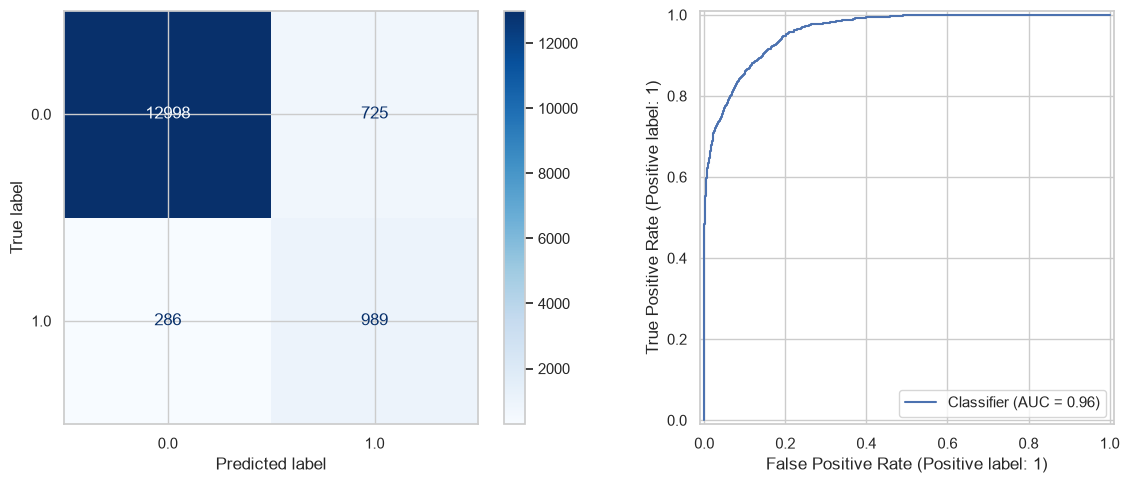

TN=12998, FP=725, FN=286, TP=989; FN là ca bệnh bị bỏ sót.


In [13]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,RocCurveDisplay
test_prob=forward(Xte,params)[0]; test_metrics,test_pred=metrics(yte,test_prob,best_threshold)
display(pd.Series(test_metrics,name="Deep MLP test").round(4)); print(classification_report(yte.ravel().astype(int),test_pred,digits=4))
fig,ax=plt.subplots(1,2,figsize=(12,5)); ConfusionMatrixDisplay.from_predictions(yte.ravel(),test_pred,ax=ax[0],cmap="Blues"); RocCurveDisplay.from_predictions(yte.ravel(),test_prob.ravel(),ax=ax[1]); plt.tight_layout(); plt.show()
tn,fp,fn,tp=confusion_matrix(yte.ravel(),test_pred).ravel(); print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}; FN là ca bệnh bị bỏ sót.")

## 14. Exercise 2 - thay đổi learning rate

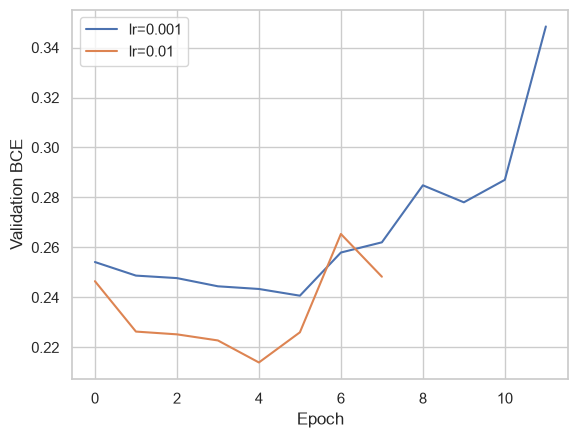

In [14]:
lr_runs={.001:history}
for lr in [.01]:
    _,h,_,_=train_network(Xtr,ytr,Xv,yv,architecture,lr=lr,epochs=8 if FAST_MODE else 40,batch_size=256,weighted=True)
    lr_runs[lr]=h
for lr,h in lr_runs.items(): plt.plot(h["validation"],label=f"lr={lr}")
plt.xlabel("Epoch"); plt.ylabel("Validation BCE"); plt.legend(); plt.show()

## 15. Exercise 3 - mạng 5 tầng so với mạng nông

In [15]:
shallow=[d,32,16,1]
p_shallow,h_shallow,_,_=train_network(Xtr,ytr,Xv,yv,shallow,lr=.001,epochs=8 if FAST_MODE else 40,batch_size=256,weighted=True)
deep_m,_=metrics(yv,val_prob,best_threshold); shallow_m,_=metrics(yv,forward(Xv,p_shallow)[0],best_threshold)
display(pd.DataFrame([deep_m,shallow_m],index=["5 trainable layers","3 trainable layers"]).round(4))
print("Mạng sâu hơn có capacity lớn hơn nhưng không đảm bảo tổng quát tốt hơn trên tabular data.")

,Accuracy,Precision,Recall,F1,F2,ROC-AUC
5 trainable layers,0.9358,0.5912,0.7929,0.6774,0.7423,0.9651
3 trainable layers,0.9405,0.6253,0.7475,0.6810,0.7194,0.9611


Mạng sâu hơn có capacity lớn hơn nhưng không đảm bảo tổng quát tốt hơn trên tabular data.


## 16. Exercise 4 - weighted BCE so với unweighted BCE

In [16]:
p_unweighted,h_unweighted,_,_=train_network(Xtr,ytr,Xv,yv,architecture,lr=.001,epochs=8 if FAST_MODE else 40,batch_size=256,weighted=False)
weighted_m,_=metrics(yv,val_prob,best_threshold); unweighted_m,_=metrics(yv,forward(Xv,p_unweighted)[0],best_threshold)
display(pd.DataFrame([weighted_m,unweighted_m],index=["Weighted BCE","Unweighted BCE"]).round(4))
print("Accuracy có thể cao trong khi Recall lớp bệnh thấp; không chọn loss chỉ dựa trên accuracy.")

,Accuracy,Precision,Recall,F1,F2,ROC-AUC
Weighted BCE,0.9358,0.5912,0.7929,0.6774,0.7423,0.9651
Unweighted BCE,0.9628,0.9650,0.5835,0.7273,0.6336,0.9657


Accuracy có thể cao trong khi Recall lớp bệnh thấp; không chọn loss chỉ dựa trên accuracy.


## 17. Exercise 5 - inspect learned representations

In [17]:
_,_,hidden=forward(Xtr[:256],params,return_hidden=True)
for i,H in enumerate(hidden,1): print(f"H{i}.shape =",H.shape,"zero fraction =",round(float((H==0).mean()),3))
print("Các tầng nén representation theo chuỗi 128→64→32→16; zero fraction đến từ ReLU.")

H1.shape = (256, 128) zero fraction = 0.522
H2.shape = (256, 64) zero fraction = 0.472
H3.shape = (256, 32) zero fraction = 0.409
H4.shape = (256, 16) zero fraction = 0.524
Các tầng nén representation theo chuỗi 128→64→32→16; zero fraction đến từ ReLU.


## 18. Baseline Classical ML và đối sánh

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

baselines = {
    "Logistic Regression": LogisticRegression(
        max_iter=1500,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=12,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=SEED
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=120,
        max_depth=18,
        min_samples_leaf=3,
        n_jobs=-1,
        class_weight="balanced",
        random_state=SEED
    )
}

# Thêm kết quả MLP 5 tầng
rows = [
    {
        "Model": "Deep MLP 5-layer",
        **test_metrics
    }
]

# Huấn luyện và đánh giá 3 mô hình ML
for name, model in baselines.items():
    model.fit(Xtr, ytr.ravel().astype(int))

    probability = model.predict_proba(Xte)[:, 1]

    model_metrics, _ = metrics(
        yte,
        probability,
        best_threshold
    )

    rows.append({
        "Model": name,
        **model_metrics
    })

# Sắp xếp theo F2
comparison = (
    pd.DataFrame(rows)
    .sort_values("F2", ascending=False)
    .reset_index(drop=True)
)

display(comparison.round(4))

print(
    "Đối sánh MLP 5 tầng với Logistic Regression, "
    "Decision Tree và Random Forest."
)

,Model,Accuracy,Precision,Recall,F1,F2,ROC-AUC
0,Decision Tree,0.9613,0.7983,0.7294,0.7623,0.7422,0.9494
1,Deep MLP 5-layer,0.9326,0.5770,0.7757,0.6618,0.7257,0.9609
2,Logistic Regression,0.9475,0.6800,0.7216,0.7002,0.7128,0.9582
3,Random Forest,0.9691,0.9666,0.6588,0.7836,0.7036,0.9703


Đối sánh MLP 5 tầng với Logistic Regression, Decision Tree và Random Forest.


## 19. Lưu preprocessing, model và cấu hình suy luận

In [19]:
artifact={"preprocessor":prep,"params":params,"architecture":architecture,"threshold":best_threshold,"class_weights":class_weights,"feature_columns":X.columns.tolist(),"target":"diabetes"}
model_path=MODEL_DIR/"numpy_mlp_5layers_diabetes.joblib"; joblib.dump(artifact,model_path)
loaded=joblib.load(model_path); assert loaded["architecture"]==architecture and loaded["threshold"]==best_threshold
print("Saved and reload-verified:",model_path)

Saved and reload-verified: C:\Users\hhai6\models\numpy_mlp_5layers_diabetes.joblib


## 20. Hàm inference dùng cho FastAPI

In [20]:
def predict_patient(raw_patient,artifact):
    row=pd.DataFrame([raw_patient],columns=artifact["feature_columns"])
    z=artifact["preprocessor"].transform(row).astype(np.float32)
    prob=float(forward(z,artifact["params"])[0][0,0])
    return {"prediction":int(prob>=artifact["threshold"]),"probability":prob,"threshold":artifact["threshold"]}

example=Xte_df.iloc[0].to_dict(); print(predict_patient(example,loaded))

{'prediction': 0, 'probability': 0.17940737307071686, 'threshold': 0.8}


## 21. Kết luận và checklist báo cáo

1. Báo cáo dữ liệu gốc `(N, 16)`, một vector bệnh nhân và `d` thực tế sau encoding.
2. Trình bày tensor shapes qua đủ 5 tầng có tham số.
3. Giải thích vì sao preprocessing chỉ fit trên train và test không dùng để tuning.
4. Phân tích mất cân bằng, weighted BCE, threshold trade-off và false negative.
5. Báo cáo Accuracy, Precision, Recall, F1, F2, ROC-AUC và confusion matrix.
6. So sánh MLP với Logistic Regression/Random Forest bằng kết quả chạy thật.
7. Nêu best epoch, dấu hiệu overfitting và vai trò early stopping.
8. Lưu cả preprocessing, params, architecture và threshold để FastAPI dùng đúng logic huấn luyện.

### Giới hạn

- Mô hình chỉ phản ánh dataset, không tự động khái quát cho mọi dân số.
- Location/year có thể tạo dataset shift theo thời gian và địa lý.
- Cần calibration, kiểm tra fairness, validation ngoại bộ và giám sát drift trước ứng dụng y tế thật.